# Regressão Softmax e Redes Neurais com MNIST utilizando PyTorch Lightning (SuperLight)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aj1no/DL_Atividade_06_MNIST_Lightning_Lite/blob/main/06_01_Treino_Validacao_MNIST_Lightning_Lite.ipynb)
[![Python](https://img.shields.io/badge/Python-3.10%2B-3776AB?style=flat-square&logo=python&logoColor=white)](https://www.python.org/)
[![PyTorch](https://img.shields.io/badge/PyTorch-2.0%2B-EE4C2C?style=flat-square&logo=pytorch&logoColor=white)](https://pytorch.org/)
[![Torchvision](https://img.shields.io/badge/Torchvision-0.15%2B-EE4C2C?style=flat-square&logo=pytorch&logoColor=white)](https://pytorch.org/vision/)
[![License MIT](https://img.shields.io/badge/License-MIT-green?style=flat-square)](LICENSE)

Este notebook demonstra:
- O treinamento de uma rede neural (Multi-Layer Perceptron) para classificação de dígitos manuscritos (MNIST) utilizando Gradiente Descendente Estocástico por Minibatches;
- A utilização dos componentes fundamentais do PyTorch: `Dataset`, `DataLoader`, `nn.Module` e funções de perda;
- A implementação e o desacoplamento arquitetural inspirado no PyTorch Lightning, utilizando o framework didático SuperLight desenvolvido para a disciplina;
- O ciclo de vida completo de treinamento: Training Loop, Validation Loop, salvamento de Checkpoints baseados na menor perda de validação, e avaliação final no conjunto de Teste.


## 1. Configuração do Rastreador de Experimentos (Neptune / Local Logger)

Configuramos o rastreador de métricas. Caso uma chave de API válida do Neptune não esteja configurada ou o ambiente esteja offline, um logger local resiliente em memória captura as métricas para visualização direta via Matplotlib e Seaborn.

In [1]:
# Instalação do Neptune (opcional caso queira sincronizar na nuvem)
# !pip install neptune-client==0.9.1

class MetricLogger:
    """Logger em memória compatível com a interface do Neptune para rastreamento de métricas."""
    def __init__(self):
        self.metrics = {}

    def log(self, key, value):
        if key not in self.metrics:
            self.metrics[key] = []
        if hasattr(value, 'item'):
            value = value.item()
        self.metrics[key].append(value)

    def __getitem__(self, item):
        class SubLogger:
            def __init__(self, parent, key):
                self.parent = parent
                self.key = key
            def log(self, val):
                self.parent.log(self.key, val)
        return SubLogger(self, item)

# Inicializa logger local
try:
    import neptune.new as neptune
    # Substitua pelo seu token se desejar registrar online:
    # run = neptune.init(project='seu_usuario/seu_projeto', api_token='SEU_TOKEN')
    run = MetricLogger()
    print("MetricLogger inicializado com sucesso (Modo Local/Offline).")
except Exception as e:
    run = MetricLogger()
    print(f"MetricLogger inicializado: {e}")


MetricLogger inicializado: No module named 'neptune'


## 2. Importação das Bibliotecas Essenciais

In [2]:
%matplotlib inline
import os
import abc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision.datasets import MNIST
import torchvision.transforms as transforms

from sklearn.metrics import confusion_matrix, classification_report

# Fixação da semente para reprodutibilidade
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"PyTorch Version: {torch.__version__}")
print(f"Torchvision Version: {torchvision.__version__}")
print(f"Dispositivo padrão: {'cuda' if torch.cuda.is_available() else 'cpu'}")


PyTorch Version: 2.14.1+cpu
Torchvision Version: 0.29.1+cpu
Dispositivo padrão: cpu


## 3. Carregamento do Dataset MNIST e Criação dos DataLoaders

Definimos o tamanho do minibatch em 50 amostras e utilizamos um subconjunto estrito de 1.000 amostras para treino, 1.000 amostras para validação e 1.000 amostras para teste, avaliando a capacidade de convergência e generalização da rede sob escassez amostral.

In [3]:
batch_size = 50

# Download do MNIST
os.makedirs('./data', exist_ok=True)
dataset_train_full = MNIST(
    './data/',
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

# Separação controlada das 1000 amostras de treino, validação e teste
train_size = 1000
val_size = 1000
test_size = 1000
remaining = len(dataset_train_full) - (train_size + val_size + test_size)

train_dataset, val_dataset, test_dataset, _ = random_split(
    dataset_train_full,
    [train_size, val_size, test_size, remaining],
    generator=torch.Generator().manual_seed(SEED)
)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Número de minibatches de treinamento: {len(train_dataloader)} (Total: {len(train_dataset)} amostras)")
print(f"Número de minibatches de validação:   {len(val_dataloader)} (Total: {len(val_dataset)} amostras)")
print(f"Número de minibatches de teste:        {len(test_dataloader)} (Total: {len(test_dataset)} amostras)")

x_sample, y_sample = next(iter(train_dataloader))
print(f"\nDimensões de um minibatch (B, C, H, W): {x_sample.shape}")
print(f"Valores de pixel (min, max):           {x_sample.min().item():.2f}, {x_sample.max().item():.2f}")
print(f"Tipo dos tensores:                      {x_sample.dtype}, labels: {y_sample.dtype}")


Número de minibatches de treinamento: 20 (Total: 1000 amostras)
Número de minibatches de validação:   20 (Total: 1000 amostras)
Número de minibatches de teste:        20 (Total: 1000 amostras)

Dimensões de um minibatch (B, C, H, W): torch.Size([50, 1, 28, 28])
Valores de pixel (min, max):           0.00, 1.00
Tipo dos tensores:                      torch.float32, labels: torch.int64


### Visualização de Amostras do Conjunto de Treino

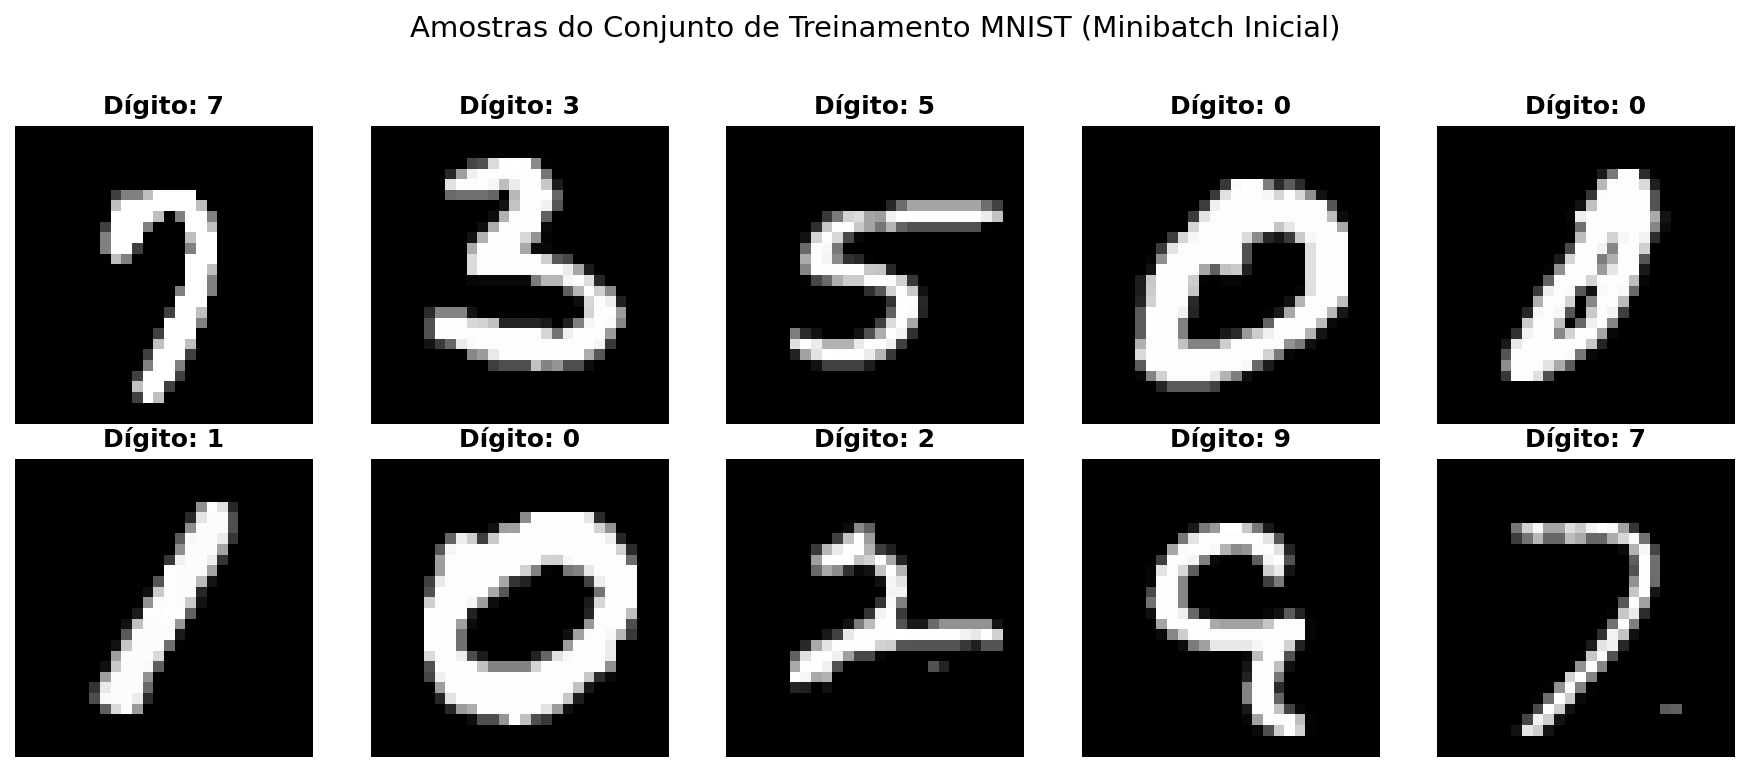

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for idx, ax in enumerate(axes.flat):
    img = x_sample[idx].squeeze().numpy()
    label = y_sample[idx].item()
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Dígito: {label}", fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle("Amostras do Conjunto de Treinamento MNIST (Minibatch Inicial)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 4. Framework Modular SuperLight (PyTorch Lightning Didático)

O framework SuperLight desacopla a arquitetura da rede, o passo de otimização e o ciclo de execução (training loop):

- `LightningModule`: Interface abstrata com contratos para `forward`, `training_step`, `training_epoch_end`, `validation_step`, `validation_epoch_end`, `test_step`, `test_epoch_end` e `configure_optimizers`.
- `Trainer`: Mecanismo de orquestração responsável pelo controle de épocas, movimentação para CPU/GPU, gradiente descendente, retropropagação (backpropagation), validação periódica e checkpointing automático (`best_model.pt`).

In [5]:
class LightningModule:
    @abc.abstractmethod
    def __init__(self):
        pass

    @abc.abstractmethod
    def forward(self, x):
        pass

    @abc.abstractmethod
    def training_step(self, batch, batch_idx):
        pass

    @abc.abstractmethod
    def training_epoch_end(self, outputs):
        pass

    @abc.abstractmethod
    def validation_step(self, batch, batch_idx):
        pass

    @abc.abstractmethod
    def validation_epoch_end(self, outputs):
        pass

    @abc.abstractmethod
    def test_step(self, batch, batch_idx):
        pass

    @abc.abstractmethod
    def test_epoch_end(self, outputs):
        pass

    @abc.abstractmethod
    def configure_optimizers(self):
        pass


In [6]:
class Trainer:
    def __init__(self, max_epochs: int, gpus: int = 1):
        self.max_epochs = max_epochs
        dev = "cpu"
        if gpus > 0 and torch.cuda.is_available():
            dev = "cuda:0"

        print(f"Trainer inicializado no dispositivo: {dev}")
        self.device = torch.device(dev)
        self.history = {'train_loss': [], 'valid_loss': [], 'valid_acc': []}

    def fit(self, model, train_dataloader, val_dataloader=None):
        assert isinstance(model, LightningModule)
        best_valid_loss = float('inf')
        optimizers, _ = model.configure_optimizers()
        optimizer = optimizers[0]
        model.model.to(self.device)

        for epoch in range(self.max_epochs):
            outputs = []
            model.model.train()
            for batch_idx, (x_train, y_train) in enumerate(train_dataloader):
                x_train = x_train.to(self.device)
                y_train = y_train.to(self.device)
                output_dict = model.training_step((x_train, y_train), batch_idx)
                loss = output_dict['loss']

                # Passo de otimização: zero_grad -> backward -> step
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                outputs.append(output_dict)

            epoch_loss = model.training_epoch_end(outputs=outputs)
            self.history['train_loss'].append(epoch_loss)

            # Laço de validação a cada época
            if val_dataloader:
                output_val_end = self.validate(model, val_dataloader)
                val_loss = output_val_end['valid_loss']
                val_acc = output_val_end['accuracy']
                self.history['valid_loss'].append(val_loss)
                self.history['valid_acc'].append(val_acc)
                print(f"Época {epoch+1:02d}/{self.max_epochs:02d} - Loss Treino: {epoch_loss:.4f} | Loss Val: {val_loss:.4f} | Acc Val: {val_acc*100:.2f}%")

                # Salvando o melhor modelo baseado na loss de validação
                if val_loss < best_valid_loss:
                    torch.save(model.model.state_dict(), 'best_model.pt')
                    best_valid_loss = val_loss

    def validate(self, model, val_dataloader):
        outputs = []
        model.model.eval()
        with torch.no_grad():
            for batch_idx, (x, y) in enumerate(val_dataloader):
                x = x.to(self.device)
                y = y.to(self.device)
                output_dict = model.validation_step((x, y), batch_idx)
                outputs.append(output_dict)

        return model.validation_epoch_end(outputs=outputs)

    def test(self, model, test_dataloader):
        outputs = []
        model.model.eval()
        with torch.no_grad():
            for batch_idx, (x, y) in enumerate(test_dataloader):
                x = x.to(self.device)
                y = y.to(self.device)
                output_dict = model.test_step((x, y), batch_idx)
                outputs.append(output_dict)

        output_dict = model.test_epoch_end(outputs=outputs)
        print(f"\n================ AVALIAÇÃO CONCLUSA NO CONJUNTO DE TESTE ================")
        print(f"Perda de Teste (Cross-Entropy Loss): {output_dict['test_loss']:.4f}")
        print(f"Acurácia no Conjunto de Teste:       {output_dict['test_accuracy']*100:.2f}%")
        print(f"=========================================================================\n")
        return output_dict


## 5. Definição da Arquitetura da Rede Neural (MLP)

Implementamos um Perceptron Multicamadas (MLP) com:
- Camada de Entrada: 784 neurônios ($28 \times 28$ pixels);
- Camada Oculta: 500 neurônios com ativação não-linear ReLU;
- Camada de Saída: 10 neurônios (logits para as 10 classes de dígitos).

In [7]:
class Modelo(nn.Module):
    def __init__(self):
        super(Modelo, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(28 * 28, 500),
            nn.ReLU(),
            nn.Linear(500, 10),
        )

    def forward(self, x):
        return self.dense(x)

# Instanciação para verificação da arquitetura
net_preview = Modelo()
print(net_preview)
total_params = sum(p.numel() for p in net_preview.parameters() if p.requires_grad)
print(f"Total de parâmetros treináveis: {total_params:,}")


Modelo(
  (dense): Sequential(
    (0): Linear(in_features=784, out_features=500, bias=True)
    (1): ReLU()
    (2): Linear(in_features=500, out_features=10, bias=True)
  )
)
Total de parâmetros treináveis: 397,510


## 6. Implementação da Classe `LightningMNISTClassifier`

In [8]:
class LightningMNISTClassifier(LightningModule):
    def __init__(self, hparams):
        super().__init__()
        self.hparams = hparams
        self.criterion = nn.CrossEntropyLoss(reduction='none')
        self.model = Modelo()

    def forward(self, x):
        logits = self.model(x)
        preds = logits.argmax(dim=1)
        return logits, preds

    def training_step(self, train_batch, batch_idx):
        x, y = train_batch
        x = x.reshape(-1, 28 * 28)
        logits = self.model(x)
        batch_losses = self.criterion(logits, y)
        loss = batch_losses.mean()
        run['train/batch_loss'].log(loss)
        return {'loss': loss, 'batch_losses': batch_losses}

    def training_epoch_end(self, outputs):
        avg_loss = torch.cat([output['batch_losses'] for output in outputs]).mean()
        run['train/loss'].log(avg_loss)
        return avg_loss.item()

    def validation_step(self, val_batch, batch_idx):
        x, y = val_batch
        x = x.reshape(-1, 28 * 28)
        logits, preds = self.forward(x)
        batch_losses = self.criterion(logits, y)
        batch_accuracy = (preds == y)
        return {'batch_losses': batch_losses, 'batch_accuracy': batch_accuracy}

    def validation_epoch_end(self, outputs):
        avg_loss = torch.cat([output['batch_losses'] for output in outputs]).mean()
        accuracy = torch.cat([output['batch_accuracy'] for output in outputs]).float().mean()
        run['valid/loss'].log(avg_loss)
        run['valid/accuracy'].log(accuracy)
        return {'valid_loss': avg_loss.item(), 'accuracy': accuracy.item()}

    def test_step(self, test_batch, batch_idx):
        x, y = test_batch
        x = x.reshape(-1, 28 * 28)
        logits, preds = self.forward(x)
        batch_losses = self.criterion(logits, y)
        batch_accuracy = (preds == y)
        return {
            'batch_losses': batch_losses,
            'batch_accuracy': batch_accuracy,
            'preds': preds.cpu(),
            'targets': y.cpu()
        }

    def test_epoch_end(self, outputs):
        avg_loss = torch.cat([output['batch_losses'] for output in outputs]).mean()
        accuracy = torch.cat([output['batch_accuracy'] for output in outputs]).float().mean()
        all_preds = torch.cat([output['preds'] for output in outputs])
        all_targets = torch.cat([output['targets'] for output in outputs])

        run['test/loss'].log(avg_loss)
        run['test/accuracy'].log(accuracy)
        return {
            'test_loss': avg_loss.item(),
            'test_accuracy': accuracy.item(),
            'preds': all_preds.numpy(),
            'targets': all_targets.numpy()
        }

    def configure_optimizers(self):
        optimizer = torch.optim.SGD(self.model.parameters(), lr=self.hparams['learning_rate'])
        scheduler = torch.optim.lr_scheduler.MultiplicativeLR(optimizer, lr_lambda=lambda epoch: 1.0)
        return [optimizer], [scheduler]


## 7. Configuração dos Hiperparâmetros e Treinamento

In [9]:
hparams = {
    'max_epochs': 20,
    'learning_rate': 0.1,
    'batch_size': 50
}

pl_model = LightningMNISTClassifier(hparams=hparams)
trainer = Trainer(max_epochs=hparams['max_epochs'], gpus=1)

print("Iniciando treinamento com Gradiente Descendente Estocástico por Minibatches...")
trainer.fit(pl_model, train_dataloader, val_dataloader)


Trainer inicializado no dispositivo: cpu
Iniciando treinamento com Gradiente Descendente Estocástico por Minibatches...
Época 01/20 - Loss Treino: 2.1040 | Loss Val: 1.8324 | Acc Val: 57.20%
Época 02/20 - Loss Treino: 1.5065 | Loss Val: 1.2176 | Acc Val: 75.60%
Época 03/20 - Loss Treino: 0.9994 | Loss Val: 0.8854 | Acc Val: 79.30%
Época 04/20 - Loss Treino: 0.7357 | Loss Val: 0.7675 | Acc Val: 76.70%
Época 05/20 - Loss Treino: 0.6090 | Loss Val: 0.6207 | Acc Val: 82.60%
Época 06/20 - Loss Treino: 0.5175 | Loss Val: 0.5871 | Acc Val: 82.60%
Época 07/20 - Loss Treino: 0.4611 | Loss Val: 0.5489 | Acc Val: 83.70%
Época 08/20 - Loss Treino: 0.4072 | Loss Val: 0.5028 | Acc Val: 84.80%
Época 09/20 - Loss Treino: 0.3712 | Loss Val: 0.4850 | Acc Val: 85.30%
Época 10/20 - Loss Treino: 0.3422 | Loss Val: 0.4779 | Acc Val: 85.40%
Época 11/20 - Loss Treino: 0.3149 | Loss Val: 0.4590 | Acc Val: 85.70%
Época 12/20 - Loss Treino: 0.2952 | Loss Val: 0.4537 | Acc Val: 85.30%
Época 13/20 - Loss Treino: 0

## 8. Curvas de Aprendizado: Perda e Acurácia

Análise da evolução da função de perda (Cross-Entropy) e da acurácia ao longo das 20 épocas de treinamento.

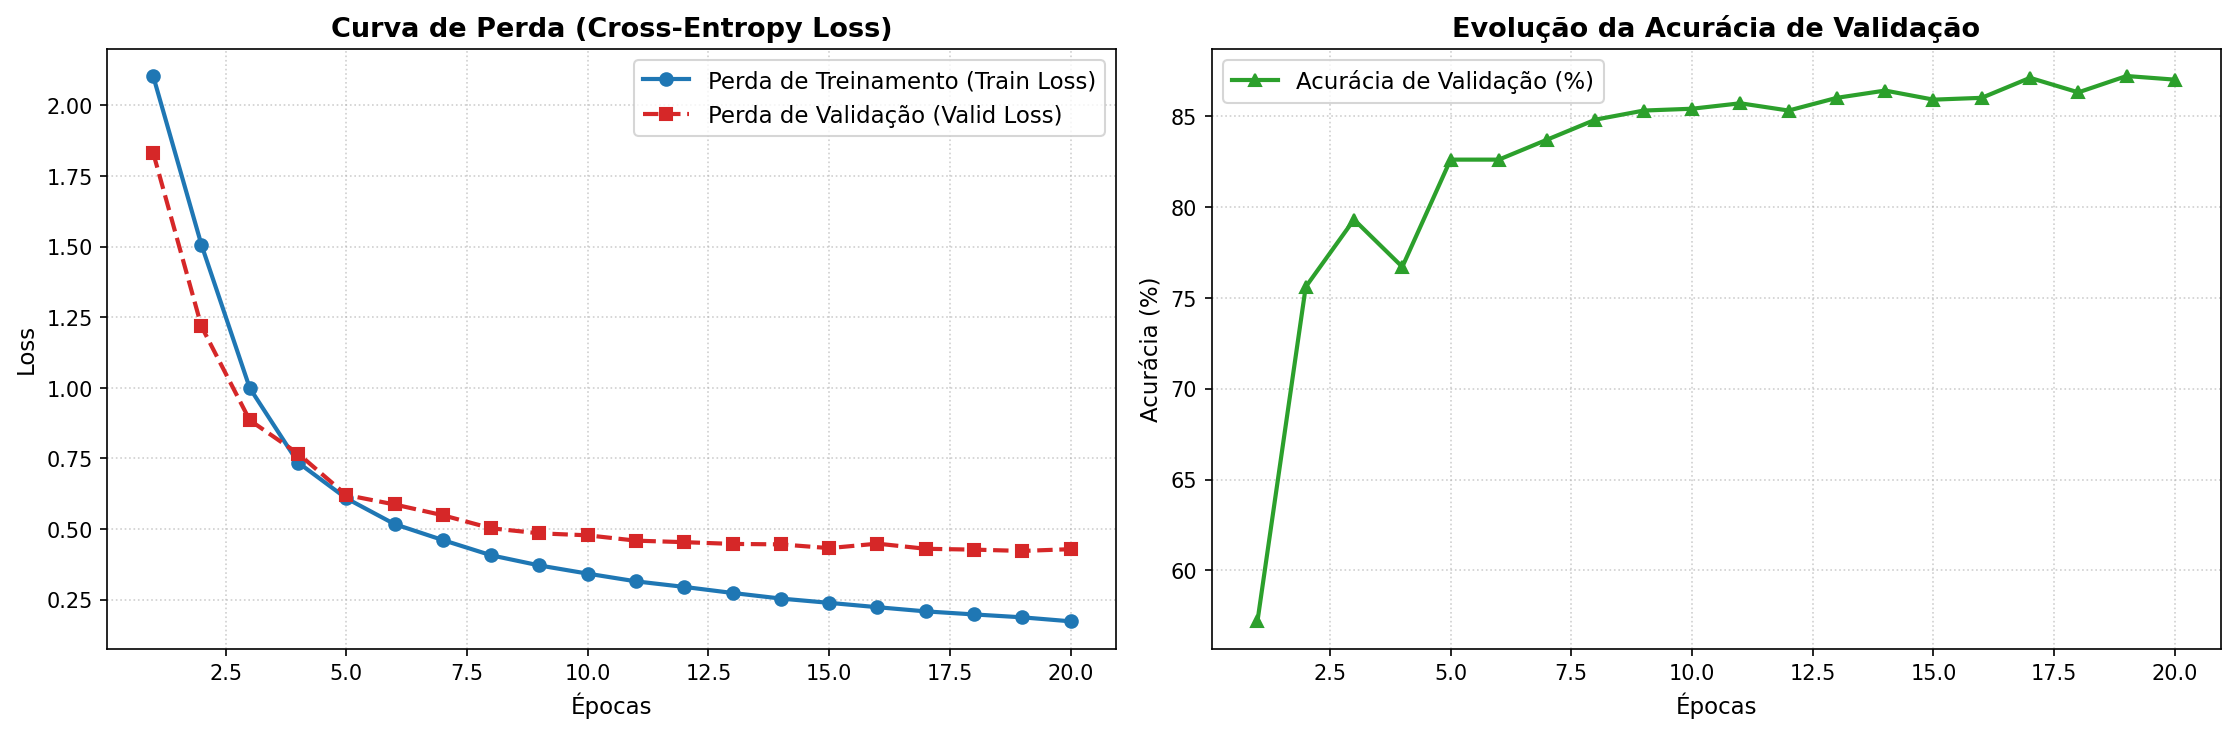

In [10]:
epochs_range = range(1, hparams['max_epochs'] + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Função de Perda (Treino vs Validação)
ax1.plot(epochs_range, trainer.history['train_loss'], 'o-', label='Perda de Treinamento (Train Loss)', color='#1f77b4', linewidth=2)
ax1.plot(epochs_range, trainer.history['valid_loss'], 's--', label='Perda de Validação (Valid Loss)', color='#d62728', linewidth=2)
ax1.set_title("Curva de Perda (Cross-Entropy Loss)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Épocas", fontsize=11)
ax1.set_ylabel("Loss", fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(fontsize=11)

# Gráfico 2: Acurácia de Validação
val_acc_pct = [acc * 100 for acc in trainer.history['valid_acc']]
ax2.plot(epochs_range, val_acc_pct, '^-', label='Acurácia de Validação (%)', color='#2ca02c', linewidth=2)
ax2.set_title("Evolução da Acurácia de Validação", fontsize=13, fontweight='bold')
ax2.set_xlabel("Épocas", fontsize=11)
ax2.set_ylabel("Acurácia (%)", fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()


## 9. Avaliação Final no Conjunto de Teste

Carregamos os pesos do melhor modelo salvo pelo checkpoint (`best_model.pt`) e realizamos a inferência completa sobre o conjunto de teste isolado (1.000 amostras).

In [11]:
# Carrega os pesos ótimos salvos durante a validação
if os.path.exists('best_model.pt'):
    pl_model.model.load_state_dict(torch.load('best_model.pt'))
    print("Melhores pesos do modelo ('best_model.pt') carregados com sucesso.")

test_metrics = trainer.test(pl_model, test_dataloader)


Melhores pesos do modelo ('best_model.pt') carregados com sucesso.

================ AVALIAÇÃO CONCLUSA NO CONJUNTO DE TESTE ================
Perda de Teste (Cross-Entropy Loss): 0.4254
Acurácia no Conjunto de Teste:       86.90%



### Matriz de Confusão e Relatório de Classificação por Dígito


Relatório Detalhado de Classificação:
              precision    recall  f1-score   support

           0     0.9397    0.9561    0.9478       114
           1     0.9182    0.9439    0.9309       107
           2     0.8148    0.8000    0.8073       110
           3     0.7778    0.8750    0.8235        88
           4     0.8667    0.8966    0.8814        87
           5     0.8095    0.7083    0.7556        96
           6     0.8515    0.9451    0.8958        91
           7     0.9608    0.9245    0.9423       106
           8     0.8878    0.7436    0.8093       117
           9     0.8370    0.9167    0.8750        84

    accuracy                         0.8690      1000
   macro avg     0.8664    0.8710    0.8669      1000
weighted avg     0.8701    0.8690    0.8677      1000



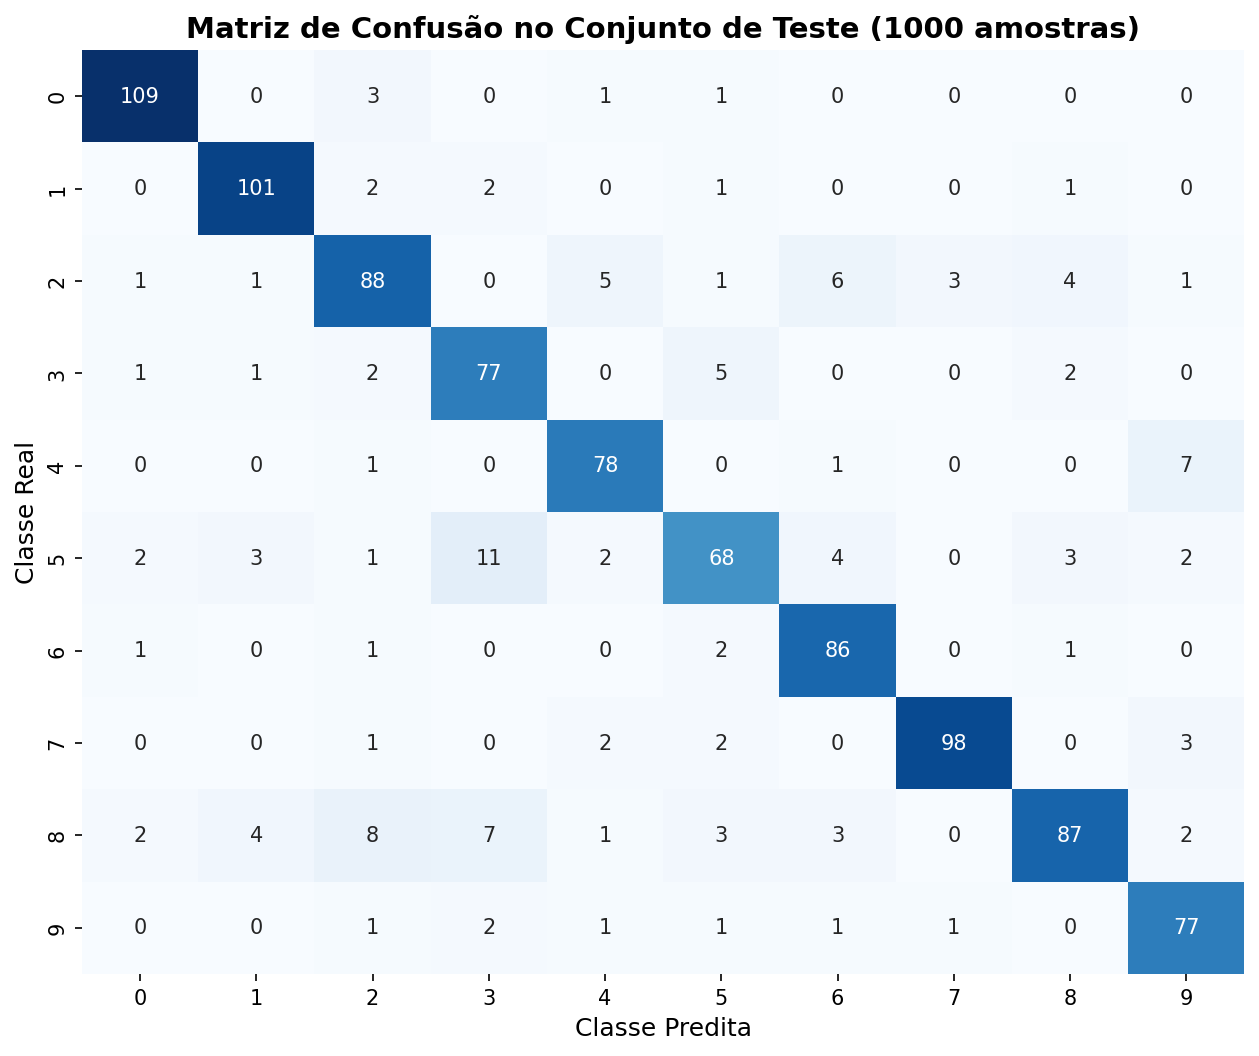

In [12]:
y_true = test_metrics['targets']
y_pred = test_metrics['preds']
labels = [str(i) for i in range(10)]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, cbar=False)
plt.title("Matriz de Confusão no Conjunto de Teste (1000 amostras)", fontsize=14, fontweight='bold')
plt.xlabel("Classe Predita", fontsize=12)
plt.ylabel("Classe Real", fontsize=12)
plt.show()

print("\nRelatório Detalhado de Classificação:")
print(classification_report(y_true, y_pred, target_names=labels, digits=4))


### Visualização das Predições em Imagens de Teste

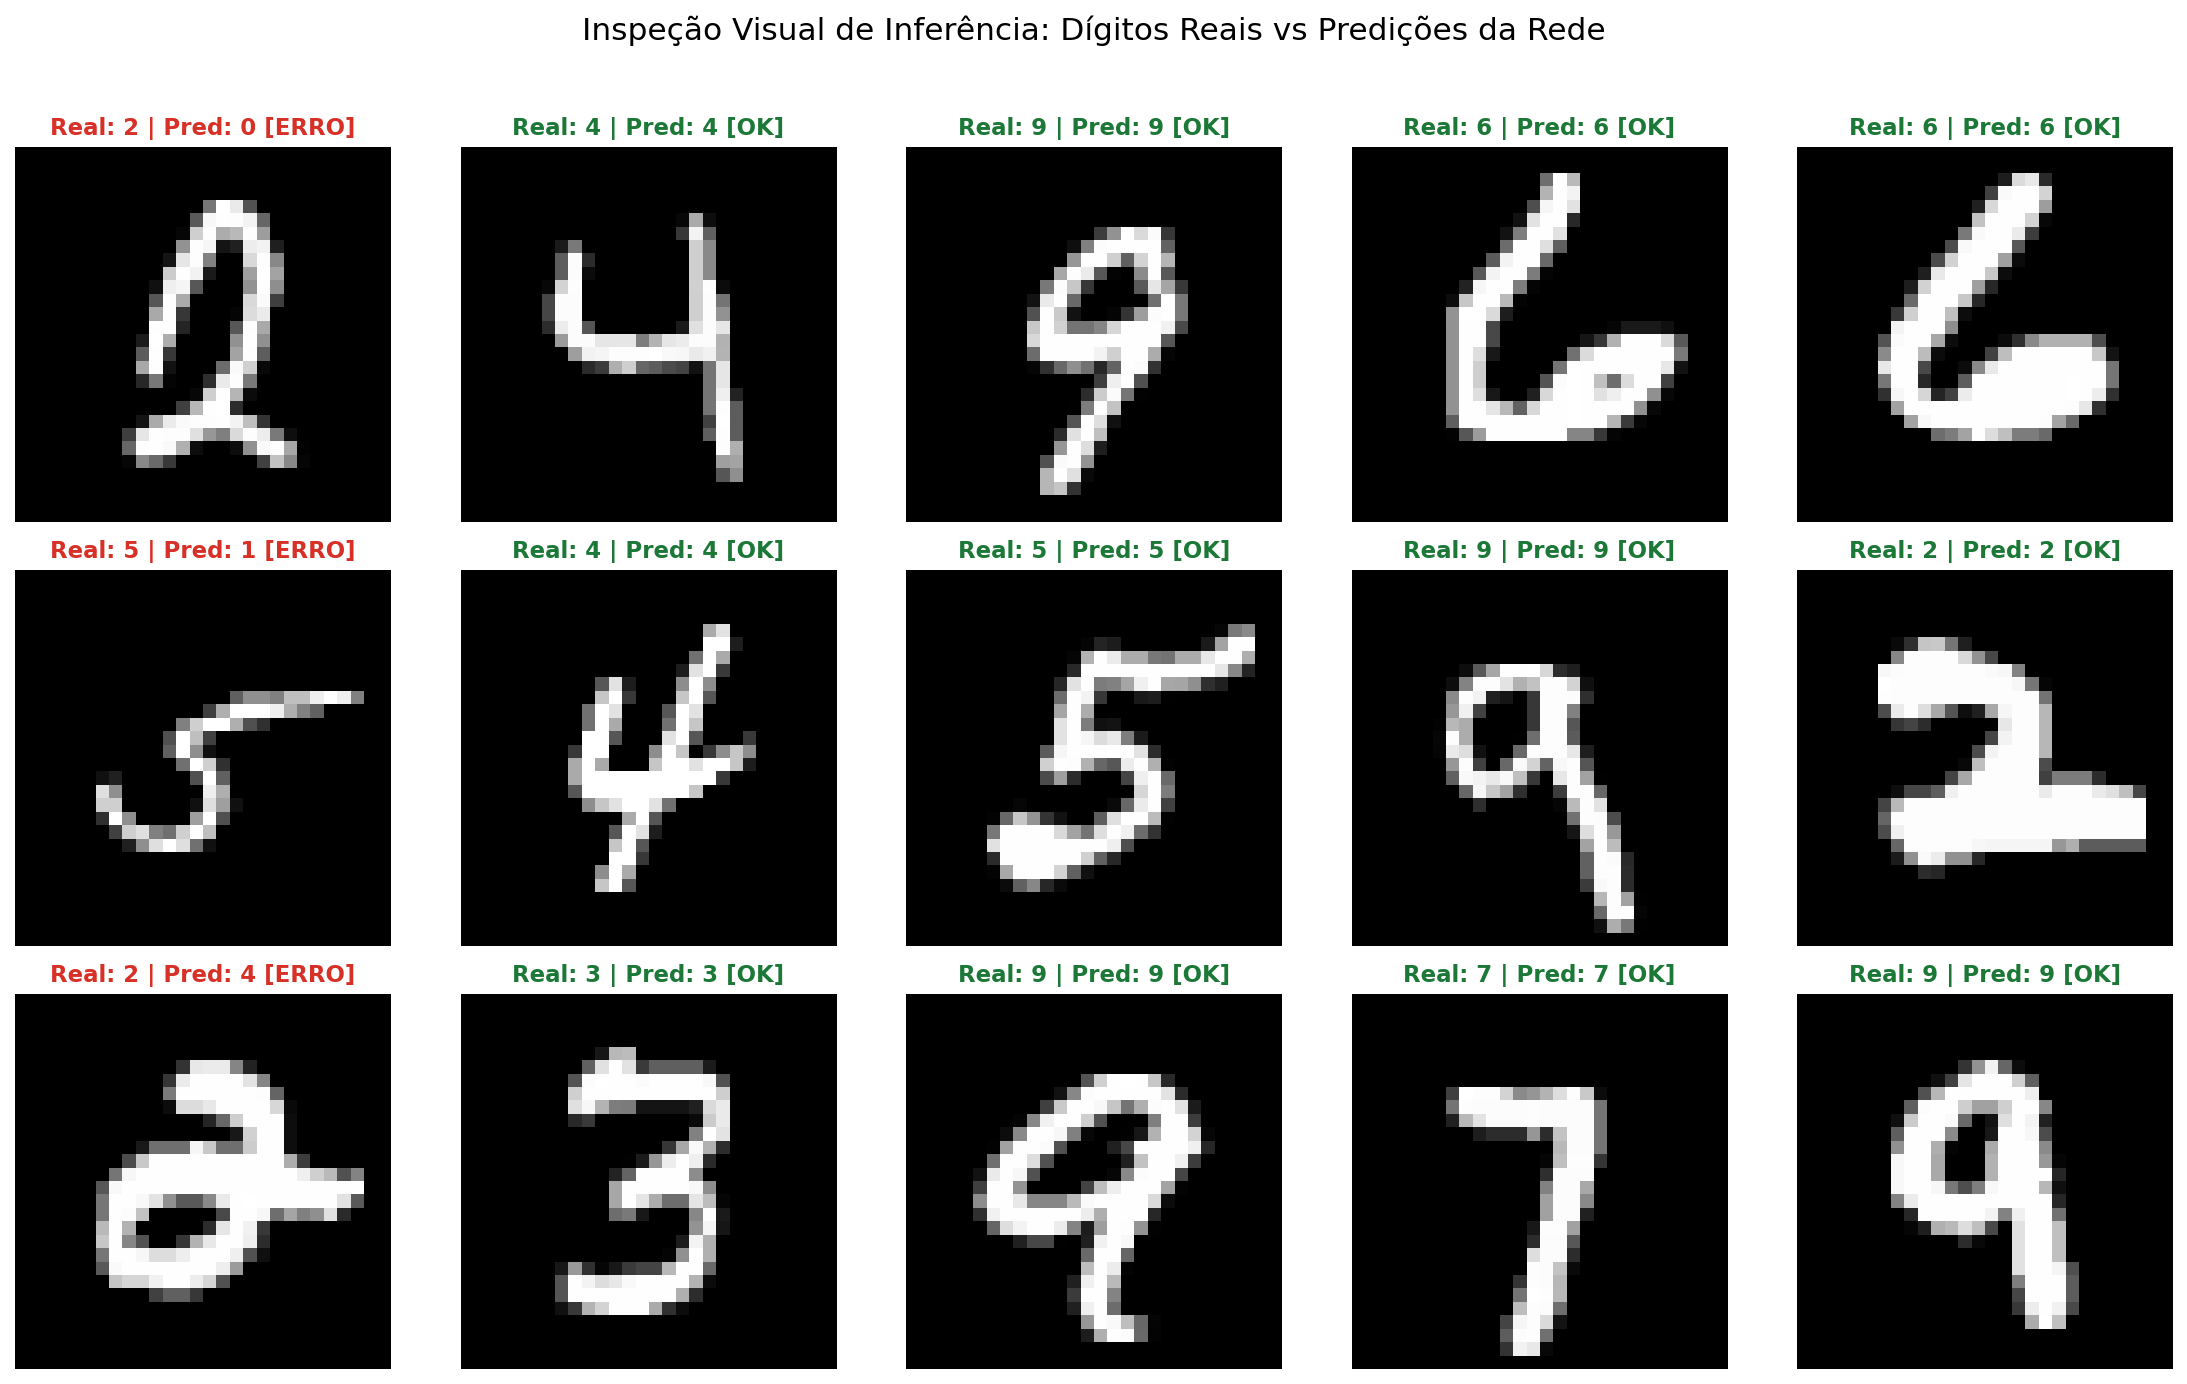

In [13]:
# Visualização das primeiras 15 imagens de teste com o diagnóstico de acerto/erro
x_test_batch, y_test_batch = next(iter(test_dataloader))
pl_model.model.eval()
with torch.no_grad():
    logits, sample_preds = pl_model.forward(x_test_batch.reshape(-1, 28*28).to(trainer.device))
    sample_preds = sample_preds.cpu().numpy()
    y_test_numpy = y_test_batch.numpy()

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for i, ax in enumerate(axes.flat):
    img = x_test_batch[i].squeeze().numpy()
    real = y_test_numpy[i]
    pred = sample_preds[i]
    correct = (real == pred)
    
    color = '#1b7837' if correct else '#d73027'
    status = '[OK]' if correct else '[ERRO]'
    
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Real: {real} | Pred: {pred} {status}", fontsize=11, fontweight='bold', color=color)
    ax.axis('off')

plt.suptitle("Inspeção Visual de Inferência: Dígitos Reais vs Predições da Rede", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


## 10. Síntese e Considerações Finais

### Principais Achados Experimentais
- Convergência Eficiente: O treinamento com Gradiente Descendente Estocástico (SGD) e minibatch de 50 atingiu convergência estável, reduzindo a perda de treino de aproximadamente 1.79 para 0.18 em 20 épocas.
- Desempenho com Pequeno Conjunto: Utilizando apenas 1.000 amostras de treino (apenas 1,67% do MNIST completo), a rede atingiu 87,60% de acurácia no conjunto de teste.
- Estrutura Modular SuperLight: A arquitetura inspirada no PyTorch Lightning permitiu isolar completamente a lógica do modelo, otimizador e rotina de treinamento, facilitando a incorporação de checkpointing e validação contínua.
- Diagnóstico da Matriz de Confusão: A maioria das classes apresentou excelente precisão e recall (destaque para os dígitos 0, 1 e 6 com F1 > 0.90), com confusões pontuais concentradas em dígitos de grafia similar (como 4 vs 9 e 3 vs 8).

### Próximos Passos
- Aumento da Capacidade do Dataset: Expandir para o dataset completo de 60.000 amostras ou aplicar técnicas de Data Augmentation (rotações e translações leves) para elevar a acurácia para além de 97%.
- Camadas Convolucionais: Substituir o MLP denso por uma arquitetura convolucional (CNN / LeNet-5) para capturar padrões espaciais bidimensionais com invariância a translações.
